## Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re

from scipy.stats import chi2_contingency
from scipy.stats import kruskal

from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV

from sklearn.pipeline import Pipeline

from sklearn.impute import SimpleImputer

from sklearn.preprocessing import OrdinalEncoder
from sklearn.preprocessing import OneHotEncoder

from sklearn.compose import ColumnTransformer
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier

from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix, ConfusionMatrixDisplay, roc_auc_score

## Load Dataset

In [ ]:
df = pd.read_csv("credit_score.csv")

In [3]:
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', None)
df.head()

,Unnamed: 0,ID,Customer_ID,Month,Name,Age,SSN,Occupation,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,Num_of_Loan,Type_of_Loan,Delay_from_due_date,Num_of_Delayed_Payment,Changed_Credit_Limit,Num_Credit_Inquiries,Credit_Mix,Outstanding_Debt,Credit_Utilization_Ratio,Credit_History_Age,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Payment_Behaviour,Monthly_Balance,Credit_Score
0,0,0x20c27,CUS_0xf64,June,NaN,32,478-73-8323,Doctor,56125.5,4875.125000,8,3,18,2,"Credit-Builder Loan, and Mortgage Loan",30,14,17.89,4.0,Standard,370.22,32.014182,28 Years and 10 Months,Yes,81.822857,182.06551022025016,High_spent_Medium_value_payments,473.62413320457887,Standard
1,1,0xc518,CUS_0x697f,March,Philh,39,367-66-5050,Entrepreneur,62148.0,NaN,9,7,24,5,"Mortgage Loan, Personal Loan, Payday Loan, Personal Loan, and Home Equity Loan",56,25,_,8.0,Bad,2373.61,33.951720,16 Years and 6 Months,Yes,258.848861,195.3722153038279,High_spent_Small_value_payments,300.6789235920986,Poor
2,2,0x22663,CUS_0x7846,February,Paramadithak,45,282-14-9365,Accountant,88380.16,7471.013333,7,7,19,3,"Student Loan, Home Equity Loan, and Credit-Builder Loan",11,19,8.7,5.0,_,124.29,41.016763,NaN,Yes,129.723699,180.79874191787297,High_spent_Medium_value_payments,686.5788927990964,Standard
3,3,0x1ff7,CUS_0x3ef5,June,Robinsonl,32,259-09-9023,_______,7821.24,468.770000,8,10,29,6,"Mortgage Loan, Personal Loan, Home Equity Loan, Personal Loan, Auto Loan, and Payday Loan",62,17,19.34,7.0,Bad,2924.76,34.203026,10 Years and 2 Months,Yes,19.727923,39.93770264234067,Low_spent_Medium_value_payments,267.2113738653678,Standard
4,4,0x9a07,CUS_0x8fdf,June,Yeeo,18,312-56-4208,Scientist,107871.9,NaN,3,4,8,3,"Student Loan, Mortgage Loan, and Credit-Builder Loan",25,20,11.27,2.0,Standard,1005.83,27.237916,32 Years and 8 Months,No,227.241789,73.48570828760295,High_spent_Large_value_payments,820.9050026625811,Standard


## Data Understanding and Preprocessing

### Columns in Dataset

In [4]:
df.columns

Index(['Unnamed: 0', 'ID', 'Customer_ID', 'Month', 'Name', 'Age', 'SSN',
       'Occupation', 'Annual_Income', 'Monthly_Inhand_Salary',
       'Num_Bank_Accounts', 'Num_Credit_Card', 'Interest_Rate', 'Num_of_Loan',
       'Type_of_Loan', 'Delay_from_due_date', 'Num_of_Delayed_Payment',
       'Changed_Credit_Limit', 'Num_Credit_Inquiries', 'Credit_Mix',
       'Outstanding_Debt', 'Credit_Utilization_Ratio', 'Credit_History_Age',
       'Payment_of_Min_Amount', 'Total_EMI_per_month',
       'Amount_invested_monthly', 'Payment_Behaviour', 'Monthly_Balance',
       'Credit_Score'],
      dtype='object')

### Check Data Dimension and Data Types

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25000 entries, 0 to 24999
Data columns (total 29 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Unnamed: 0                25000 non-null  int64  
 1   ID                        25000 non-null  object 
 2   Customer_ID               25000 non-null  object 
 3   Month                     25000 non-null  object 
 4   Name                      22471 non-null  object 
 5   Age                       25000 non-null  object 
 6   SSN                       25000 non-null  object 
 7   Occupation                25000 non-null  object 
 8   Annual_Income             25000 non-null  object 
 9   Monthly_Inhand_Salary     21173 non-null  float64
 10  Num_Bank_Accounts         25000 non-null  int64  
 11  Num_Credit_Card           25000 non-null  int64  
 12  Interest_Rate             25000 non-null  int64  
 13  Num_of_Loan               25000 non-null  object 
 14  Type_o

Dataset terdiri dari **25000 baris dan 29 kolom**.
Beberapa **kolom numerik** saat ini disimpan dengan **tipe data object**, padahal **seharusnya integer atau float**. Kolom-kolom tersebut meliputi:
- **Age**
- **Annual_Income**
- **Num_of_Loan**
- **Num_of_Delayed_Payment**
- **Changed_Credit_Limit**
- **Outstanding_Debt**
- **Amount_invested_monthly**
- **Monthly_Balance**

Selain itu, dataset juga memiliki **missing values** pada beberapa kolom yaitu:
- **Name**
- **Monthly_Inhand_Salary**
- **Type_of_Loan**
- **Num_of_Delayed_Payment**
- **Num_Credit_Inquiries**
- **Credit_History_Age**
- **Amount_invested_monthly**
- **Monthly_Balance**

Selain itu, juga ditemukan **kolom yang tidak relevan atau tidak informatif**, seperti **ID, Customer_ID, Name, dan SSN**. Ini merupakan fitur-fitur yang tidak memberikan informasi yang bermakna untuk klasifikasi credit score.

### Check Duplicate

In [6]:
print("Duplicated Row : " ,df.duplicated().sum())

Duplicated Row :  0


**Tidak ada data duplikat.**

### Check Inconsistent

In [7]:
cat_cols = df.select_dtypes(include=['object']).columns

for col in cat_cols :
  print("Total Unique Values : ", df[col].nunique())
  print(df[col].value_counts())
  print()

Total Unique Values :  25000
ID
0x20c27    1
0x21529    1
0x1f806    1
0x216a8    1
0x1c080    1
          ..
0x22ce     1
0x4a32     1
0x21b41    1
0x9909     1
0x10d0c    1
Name: count, Length: 25000, dtype: int64

Total Unique Values :  11199
Customer_ID
CUS_0x8727    8
CUS_0x5e3d    7
CUS_0x6590    7
CUS_0xd40     7
CUS_0x2950    6
             ..
CUS_0xac60    1
CUS_0x9e6a    1
CUS_0x846e    1
CUS_0x1c89    1
CUS_0x2346    1
Name: count, Length: 11199, dtype: int64

Total Unique Values :  8
Month
August      3189
June        3167
January     3154
May         3152
April       3137
July        3112
February    3104
March       2985
Name: count, dtype: int64

Total Unique Values :  9014
Name
Deepa Seetharamanm    16
Stevex                15
Jessica Wohlt         14
Alexei Oreskovics     13
Chuckh                13
                      ..
Kate Holtonm           1
Tarmom                 1
N.i                    1
Michaell               1
Chanu                  1
Name: count, Length: 9

Pemeriksaan konsistensi data kategorikal menunjukkan adanya nilai tidak valid, data noise, inkonsistensi format, serta variabel numerik yang tersimpan sebagai teks.   
**Inkonsistensi data** yang ditemukan :     
- Pada **Occupation** terdapat **'_______'**
- Pada **Credit_Mix** terdapat **'_'**
- Pada **Payment_Behaviour** terdapat **'!@9#%8'**
- Pada **Payment_of_Min_Amount** terdapat **'NM'**   
Nilai-nilai ambigu ini tidak memiliki makna semantik yang jelas dan oleh karena itu nantinya diperlakukan sebagai **missing value**.

- Beberapa fitur numerik yang terdefinisikan sebagai kategorikal (**Age, Annual_Income, Num_of_Loan, Num_of_Delayed_Payment, Changed_Credit_Limit, Outstanding_Debt, Amount_invested_monthly, dan Monthly_Balance**) mengandung inkonsistensi format data. Pada fitur-fitur tersebut ditemukan nilai yang mengandung **karakter '_'**, baik sebagai **nilai tunggal** (yang dapat diinterpretasikan sebagai nilai kosong/missing), maupun **muncul di awal atau akhir nilai numerik**.

- Selain itu, terdapat **nilai anomali ekstrem** yang jelas **tidak merepresentasikan nilai numerik yang valid**, seperti **'__10000__'** pada **Amount_invested_monthly** dan **'__-333333333333333333333333333__'** pada **Monthly_Balance**. Nilai-nilai tersebut diidentifikasi sebagai noise atau placeholder tidak valid.

### Handling Inconsistencies

#### Handling Invalid Categorical Values

In [8]:
df['Occupation'] = df['Occupation'].replace('_______', np.nan)
df['Credit_Mix'] = df['Credit_Mix'].replace('_', np.nan)
df['Payment_of_Min_Amount'] = df['Payment_of_Min_Amount'].replace('NM', np.nan)
df['Payment_Behaviour'] = df['Payment_Behaviour'].replace('!@9#%8', np.nan)

Nilai seperti **'_______' pada Occupation, '_' pada Credit_Mix, 'NM' pada Payment_of_Min_Amount, dan '!@9#%8' pada Payment_Behaviour** tidak memiliki makna  yang jelas dan **tidak merepresentasikan kategori yang valid**. Oleh karena itu, nilai-nilai tersebut **dijadikan missing values** (NaN) agar dapat ditangani secara sistematis pada tahap imputasi.

#### Handling Extreme Placeholder Values

In [9]:
df['Amount_invested_monthly'] = df['Amount_invested_monthly'].replace('__10000__', np.nan)
df['Monthly_Balance'] = df['Monthly_Balance'].replace('__-333333333333333333333333333__', np.nan)

Nilai **'10000' pada Amount_invested_monthly** dan **'-333333333333333333333333333' pada Monthly_Balance** diidentifikasi sebagai **placeholder atau noise ekstrem** yang **tidak realistis**. Nilai-nilai ini tidak merepresentasikan kondisi finansial yang wajar, sehingga **dikonversi menjadi NaN** untuk mencegah distorsi distribusi data dan bias pada model.

#### Normalization of Inconsistent Numeric Formats and Data Type

In [10]:
numeric_as_object_cols = ["Age", "Annual_Income", "Num_of_Loan", "Num_of_Delayed_Payment", "Changed_Credit_Limit",
                          "Outstanding_Debt", "Amount_invested_monthly", "Monthly_Balance"]

def clean_numeric_string(value):
    if pd.isna(value):
        return np.nan

    value = str(value).strip()

    if value == "" or value.replace("_", "") == "":
        return np.nan

    value = value.replace("_", "")

    try:
        return float(value)
    except:
        return np.nan

In [11]:
for col in numeric_as_object_cols:
    df[col] = df[col].apply(clean_numeric_string)

In [12]:
for col in numeric_as_object_cols:
    df[col] = pd.to_numeric(df[col], errors="coerce")

Beberapa **fitur numerik yang tersimpan sebagai teks** mengandung karakter **'_'** sebagai bagian dari **format data**. Karakter ini **dihapus dan seluruh nilai dikonversi ke tipe numerik (float)** agar konsisten dan kompatibel dengan proses imputasi.

#### Transformation of Credit_History_Age into a Numeric Representation

In [13]:
def convert_credit_history_age(x):
    if pd.isna(x):
        return np.nan
    years = re.search(r'(\d+)\s*Years?', x)
    months = re.search(r'(\d+)\s*Months?', x)
    y = int(years.group(1)) if years else 0
    m = int(months.group(1)) if months else 0
    return y * 12 + m

df['Credit_History_Age_Months'] = df['Credit_History_Age'].apply(convert_credit_history_age)

In [14]:
df.drop(columns=['Credit_History_Age'], inplace=True)

Fitur **Credit_History_Age** disimpan dalam bentuk teks yang menggabungkan informasi tahun dan bulan. Untuk mempertahankan sifat ordinal dan kuantitatif, fitur ini **dikonversi menjadi total bulan** (**Credit_History_Age_Months**) dan kolom asli dihapus untuk menghindari redundansi.

#### Validation and Imputation of Num_of_Loan Using Type_of_Loan

In [15]:
df['Computed_Num_of_Loan'] = df['Type_of_Loan'].apply(
    lambda x: len([i for i in x.split(', ') if i.strip()])
    if pd.notnull(x) else np.nan
)

invalid_loan_mask = ((df['Num_of_Loan'] < 0) | (df['Num_of_Loan'] > 50))
df.loc[invalid_loan_mask, 'Num_of_Loan'] = np.nan
df['Num_of_Loan'] = df['Num_of_Loan'].fillna(df['Computed_Num_of_Loan'])

In [16]:
df[['Num_of_Loan', 'Type_of_Loan', 'Computed_Num_of_Loan']]

,Num_of_Loan,Type_of_Loan,Computed_Num_of_Loan
0,2.0,"Credit-Builder Loan, and Mortgage Loan",2.0
1,5.0,"Mortgage Loan, Personal Loan, Payday Loan, Personal Loan, and Home Equity Loan",5.0
2,3.0,"Student Loan, Home Equity Loan, and Credit-Builder Loan",3.0
3,6.0,"Mortgage Loan, Personal Loan, Home Equity Loan, Personal Loan, Auto Loan, and Payday Loan",6.0
4,3.0,"Student Loan, Mortgage Loan, and Credit-Builder Loan",3.0
...,...,...,...
24995,3.0,"Debt Consolidation Loan, Home Equity Loan, and Credit-Builder Loan",3.0
24996,2.0,"Auto Loan, and Home Equity Loan",2.0
24997,0.0,NaN,NaN
24998,5.0,"Auto Loan, Home Equity Loan, Home Equity Loan, Student Loan, and Payday Loan",5.0


Fitur **Type_of_Loan** merupakan **fitur berbasis teks yang tidak terstruktur dan memiliki jumlah nilai unik yang sangat tinggi**. Kondisi ini membuat fitur tersebut **kurang efektif** untuk digunakan secara langsung dalam proses pemodelan.

Oleh karena itu, fitur **Type_of_Loan** dimanfaatkan untuk menurunkan informasi jumlah pinjaman sebagai **variabel pembantu untuk memvalidasi dan mengoreksi nilai** pada fitur **Num_of_Loan**. Setelah proses validasi dan koreksi, fitur Type_of_Loan dihapus karena untuk menghindari redundansi.

In [17]:
df = df.drop(columns=['Type_of_Loan', 'Computed_Num_of_Loan'])

### Check Invalid Values

In [18]:
df.describe()

,Unnamed: 0,Age,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,Num_of_Loan,Delay_from_due_date,Num_of_Delayed_Payment,Changed_Credit_Limit,Num_Credit_Inquiries,Outstanding_Debt,Credit_Utilization_Ratio,Total_EMI_per_month,Amount_invested_monthly,Monthly_Balance,Credit_History_Age_Months
count,25000.000000,25000.000000,2.500000e+04,21173.000000,25000.000000,25000.000000,25000.000000,24886.000000,25000.000000,23256.000000,24477.000000,24503.000000,25000.000000,25000.000000,25000.000000,22787.000000,24688.000000,22751.000000
mean,12499.500000,112.199000,1.666418e+05,4168.307097,16.865000,23.311840,70.358920,3.540505,21.065360,30.069358,10.418801,26.939762,1426.928708,32.273187,1440.039648,193.845181,402.999718,221.442970
std,7217.022701,693.223151,1.352158e+06,3170.867622,114.767426,133.618787,458.469762,2.455967,14.885855,217.468823,6.802624,189.253774,1158.880154,5.114177,8514.909613,198.930866,214.400654,99.992721
min,0.000000,-500.000000,7.005930e+03,303.645417,-1.000000,0.000000,1.000000,0.000000,-5.000000,-3.000000,-6.440000,0.000000,0.230000,20.000000,0.000000,0.000000,0.599640,2.000000
25%,6249.750000,25.000000,1.953645e+04,1625.265833,4.000000,4.000000,8.000000,2.000000,10.000000,9.000000,5.380000,3.000000,566.980000,28.059564,29.912485,71.446318,270.926812,144.000000
50%,12499.500000,33.000000,3.740467e+04,3080.353333,6.000000,5.000000,13.000000,3.000000,18.000000,14.000000,9.380000,6.000000,1158.960000,32.331522,68.781136,127.276627,338.075288,220.000000
75%,18749.250000,42.000000,7.241314e+04,5927.527500,8.000000,7.000000,20.000000,5.000000,28.000000,18.000000,14.920000,9.000000,1943.080000,36.475246,160.180388,233.588643,467.668265,303.000000
max,24999.000000,8669.000000,2.419806e+07,15204.633333,1794.000000,1499.000000,5789.000000,33.000000,67.000000,4340.000000,36.970000,2553.000000,4998.070000,49.564519,82122.000000,1961.218850,1602.040519,404.000000


Terdapat **nilai numerik yang tidak realistis dan berada di luar batas logis** (invalid values) pada beberapa fitur :     
- **Age** memiliki **nilai minimum -500** dan **maksimum 8669**, yang jelas tidak masuk akal secara demografis.
- **Num_Bank_Accounts** memiliki **nilai negatif dan nilai maksimum yang sangat besar** (hingga ribuan), **jauh di luar batas wajar kepemilikan**.
- **Num_Credit_Card** memiliki **nilai maksimum yang sangat besar** (hingga ribuan), **jauh di luar batas wajar kepemilikan** kartu kredit.
- **Interest_Rate** menunjukkan **nilai maksimum yang sangat ekstrem**, mengindikasikan adanya outlier atau kesalahan pencatatan data.
- **Delay_from_due_date** dan **Changed_Credit_Limit** mengandung **nilai negatif**, yang secara konseptual **tidak valid**.
- **Num_of_Delayed_Payment** menunjukkan **nilai negatif dan nilai maksimum yang sangat tinggi**, yang tidak konsisten dengan definisi variabel.
- **Num_Credit_Inquiries** menunjukkan **nilai maksimum yang sangat tinggi**.
- **Total_EMI_per_month, Amount_invested_monthly, dan Monthly_Balance** memiliki rentang nilai yang sangat lebar dengan standar deviasi tinggi, menandakan keberadaan **outlier ekstrem**.

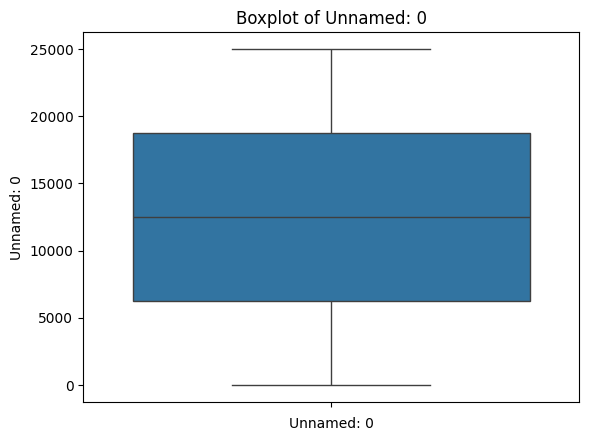

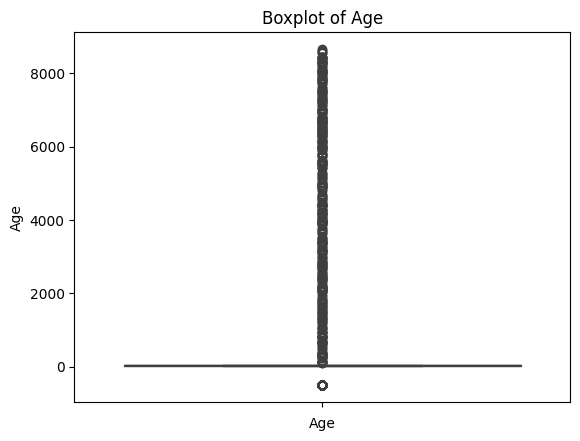

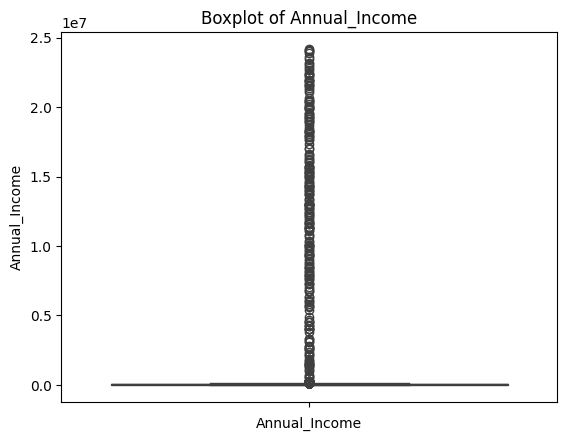

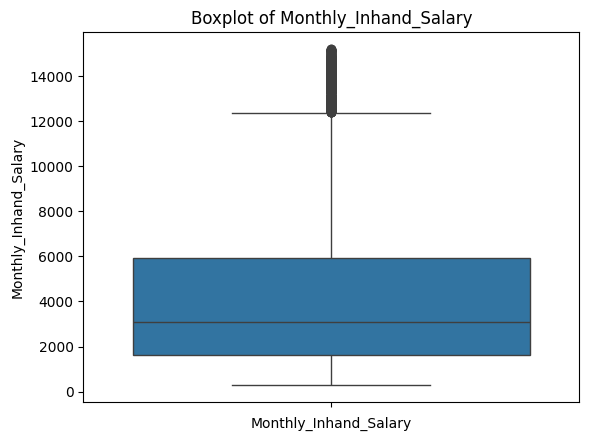

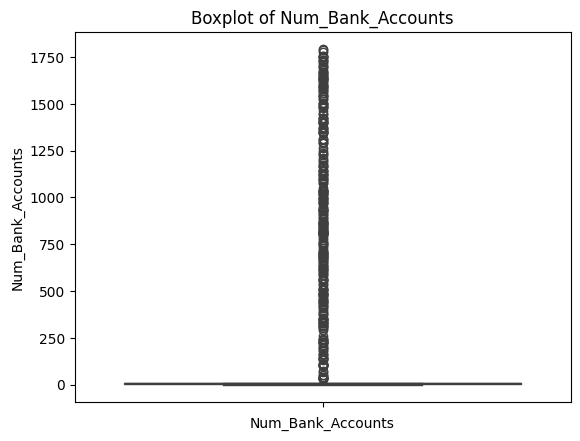

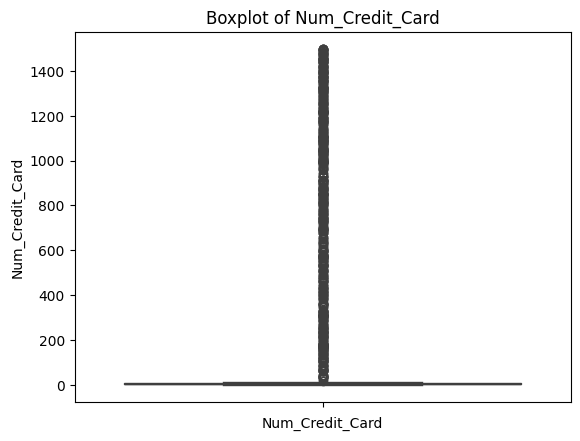

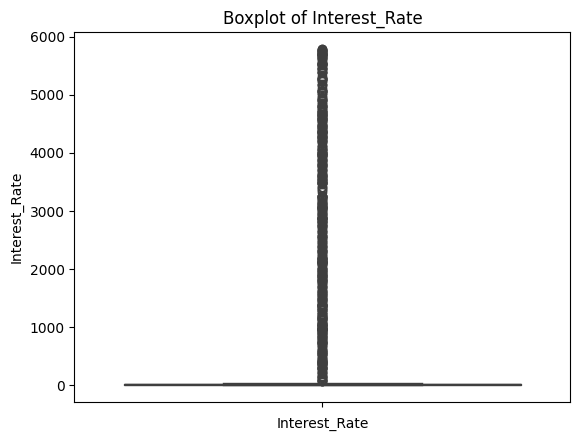

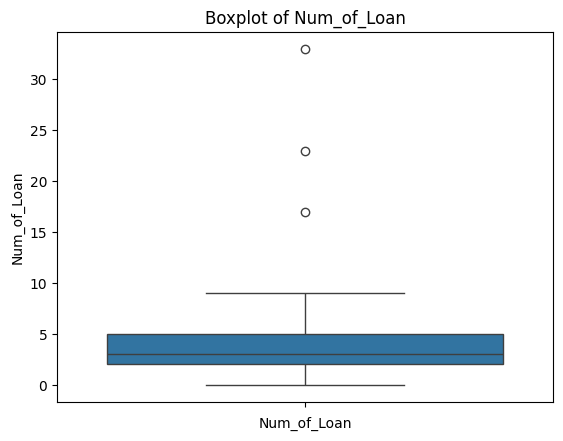

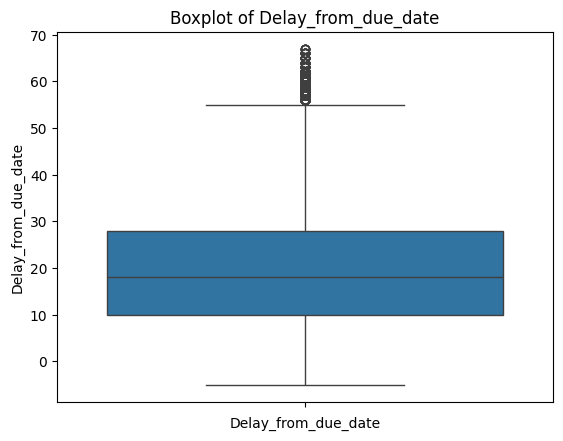

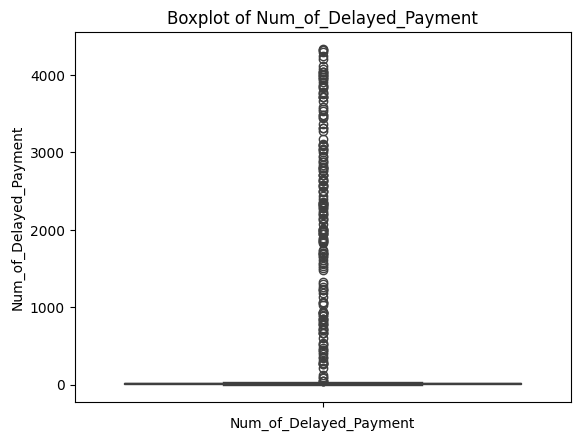

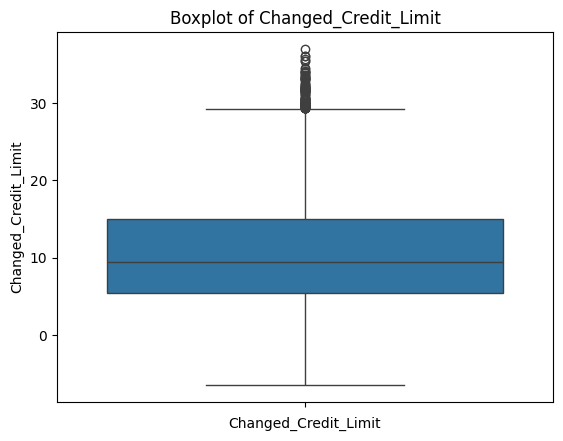

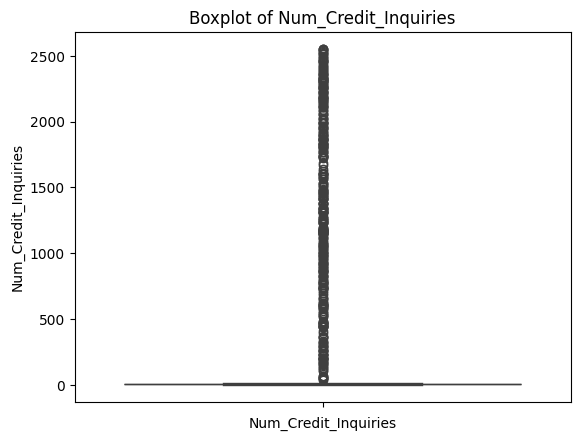

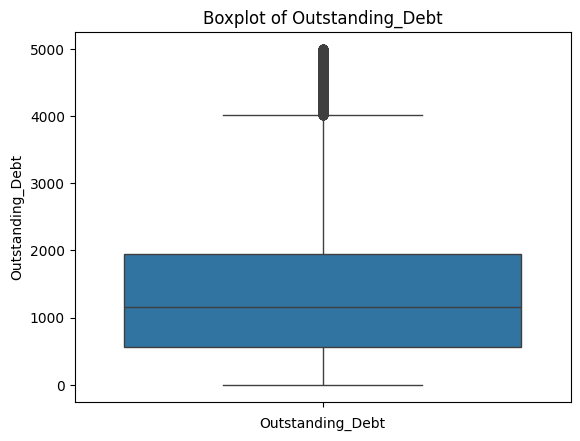

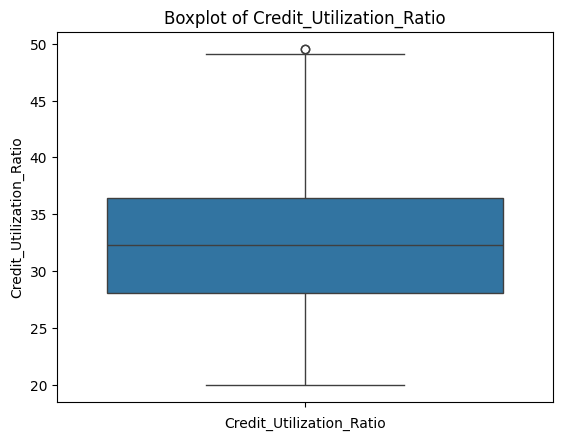

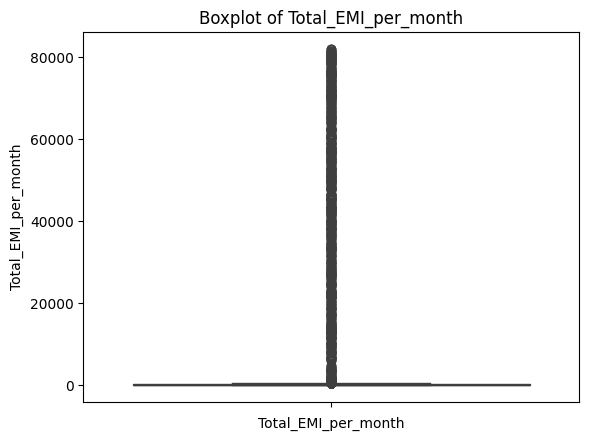

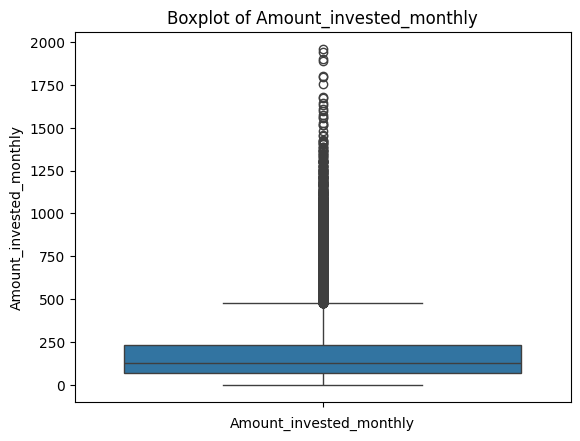

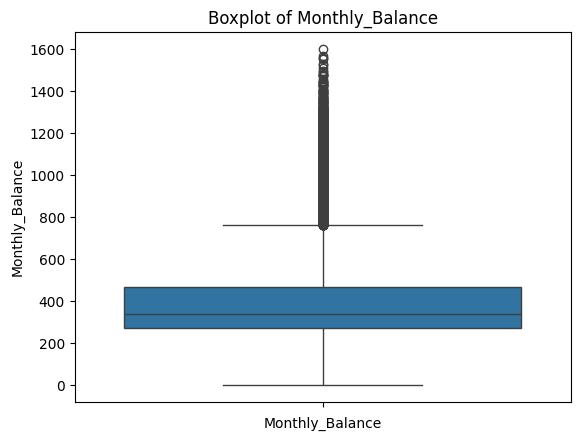

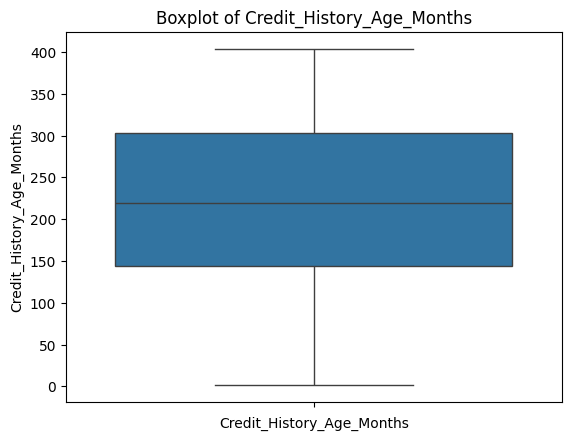

In [19]:
num_cols = df.select_dtypes(exclude=['object']).columns

for col in num_cols :
  sns.boxplot(y = df[col])
  plt.title(f'Boxplot of {col}')
  plt.xlabel(col)
  plt.show()

#### Handling Invalid Values

In [20]:
# Age di bawah 18 -> masih belum bisa melakukan kredit dan Age di atas 100 -> tidak realistis
df.loc[(df['Age'] < 18) | (df['Age'] > 100), 'Age'] = np.nan

# Number of bank accounts < 0 -> tidak bisa negatif dan > 20 -> tidak realistis
df.loc[(df['Num_Bank_Accounts'] < 0) | (df['Num_Bank_Accounts'] > 20), 'Num_Bank_Accounts'] = np.nan

# Number of credit cards > 20 -> tidak realistis
df.loc[df['Num_Credit_Card'] > 20, 'Num_Credit_Card'] = np.nan

# Credit card interest rates > 60 -> bunga sangat ekstrem
df.loc[df['Interest_Rate'] > 60, 'Interest_Rate'] = np.nan

# Delay from due date < 0 -> tidak bisa negatif
df.loc[df['Delay_from_due_date'] < 0, 'Delay_from_due_date'] = np.nan

# Number of delayed payments < 0 -> tidak bisa negatif dan > 60 -> tidak realistis
df.loc[(df['Num_of_Delayed_Payment'] < 0) | (df['Num_of_Delayed_Payment'] > 60), 'Num_of_Delayed_Payment'] = np.nan

# Changed credit limit < 0 -> tidak bisa negatif
df.loc[df['Changed_Credit_Limit'] < 0, 'Changed_Credit_Limit'] = np.nan

# Jumlah credit inquiries > 50 -> nilai sangat ekstrem
df.loc[df['Num_Credit_Inquiries'] > 50, 'Num_Credit_Inquiries'] = np.nan

**Validasi nilai numerik** dilakukan secara selektif hanya pada fitur yang secara empiris terbukti **mengandung nilai tidak masuk akal berdasarkan analisis statistik deskriptif**. Nilai-nilai tersebut ditandai sebagai **missing value (NaN)** untuk mencegah distorsi distribusi data dan memastikan proses imputasi selanjutnya berjalan secara lebih akurat.

### Check Missing Values

In [21]:
df.isnull().sum()

Unnamed: 0                      0
ID                              0
Customer_ID                     0
Month                           0
Name                         2529
Age                          2064
SSN                             0
Occupation                   1735
Annual_Income                   0
Monthly_Inhand_Salary        3827
Num_Bank_Accounts             337
Num_Credit_Card               581
Interest_Rate                 496
Num_of_Loan                   114
Delay_from_due_date           141
Num_of_Delayed_Payment       2104
Changed_Credit_Limit          911
Num_Credit_Inquiries          888
Credit_Mix                   5031
Outstanding_Debt                0
Credit_Utilization_Ratio        0
Payment_of_Min_Amount        2978
Total_EMI_per_month             0
Amount_invested_monthly      2213
Payment_Behaviour            1894
Monthly_Balance               312
Credit_Score                    0
Credit_History_Age_Months    2249
dtype: int64

Terdapat **missing values** di fitur **Name, Age, Occupation, Monthly_Inhand_Salary, Num_Bank_Accounts, Num_Credit_Card, Interest_Rate, Num_of_Loan, Delay_from_due_date, Num_of_Delayed_Payment, Changed_Credit_Limit, Num_Credit_Inquiries, Credit_Mix, Payment_of_Min_Amount, Amount_invested_monthly, Payment_Behaviour, Monthly_Balance, Credit_History_Age_Months**.

Jumlah **missing values ini  bertambah** dibandingkan di awal karena telah dilakukan **handling invalid values** (yang banyak **mengubah data menjadi NaN**).

Sebagian besar fitur memiliki jumlah **missing values yang relatif kecil** dibandingkan dengan ukuran keseluruhan dataset, sehingga **teknik imputasi** akan digunakan agar dapat mempertahankan sebanyak mungkin informasi data.

### Handling Meaningless Features

In [22]:
df = df.drop(columns=["Unnamed: 0", "ID", "Customer_ID", "Name", "SSN"])

Fitur **Unnamed: 0, ID, Customer_ID, Name, dan SSN dihapus** karena bersifat **identifier unik dan tidak mengandung informasi prediktif** terhadap Credit_Score.

### Check Target Distribution

In [23]:
df['Credit_Score'].value_counts(normalize=True)

Credit_Score
Standard    0.53220
Poor        0.28924
Good        0.17856
Name: proportion, dtype: float64

Terdapat masalah **Imbalanced Data**. Distribusi target Credit_Score menunjukkan **ketidakseimbangan kelas (class imbalance)**, di mana kategori **Standard** mendominasi dataset (**±53%**), diikuti oleh **Poor** (**±29%**) dan **Good** (**±18%**). Meskipun ketidakseimbangan ini tidak ekstrem, kondisi tersebut tetap **perlu diperhatikan** karena berpotensi memengaruhi kinerja model, khususnya dalam memprediksi kelas minoritas.

## EDA

### Distribution

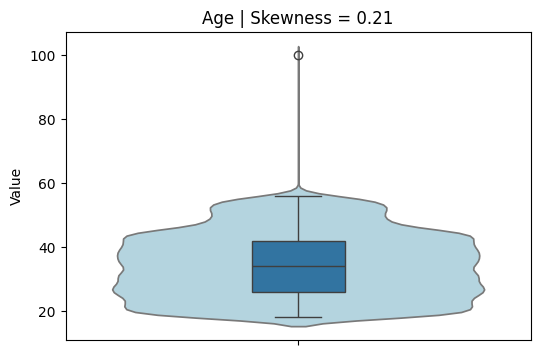

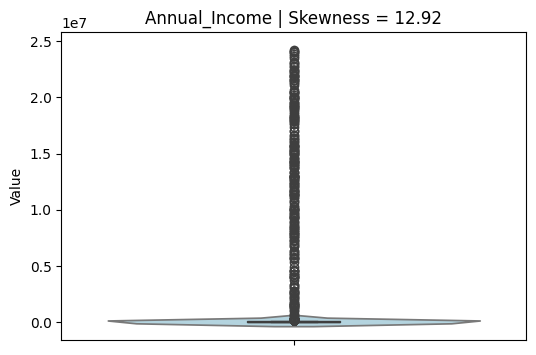

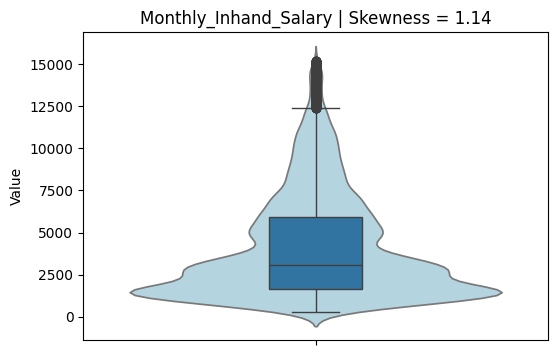

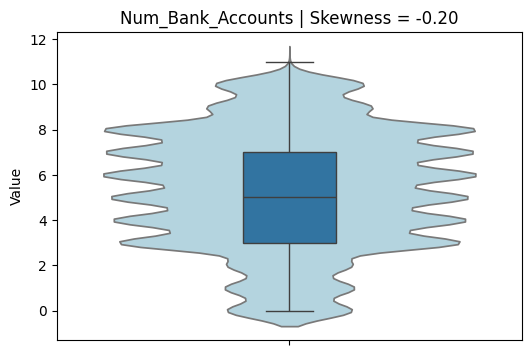

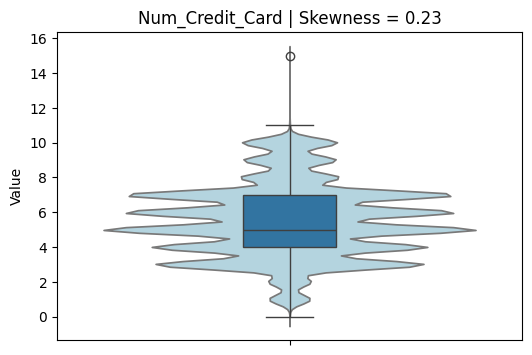

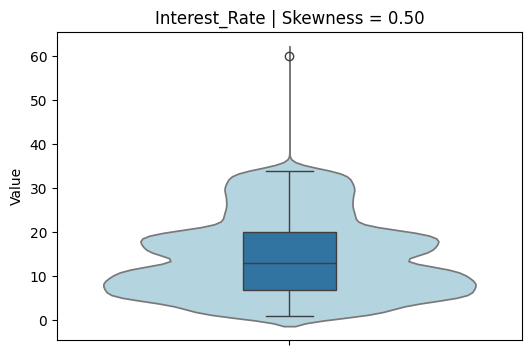

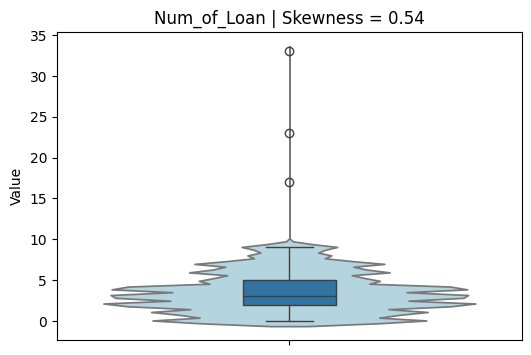

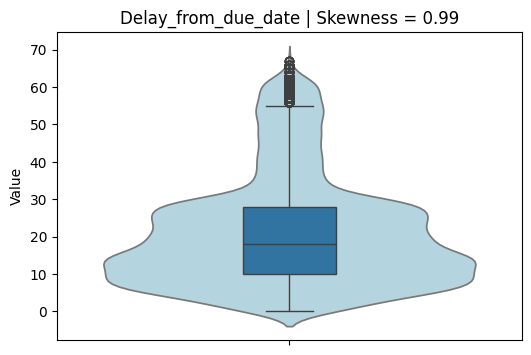

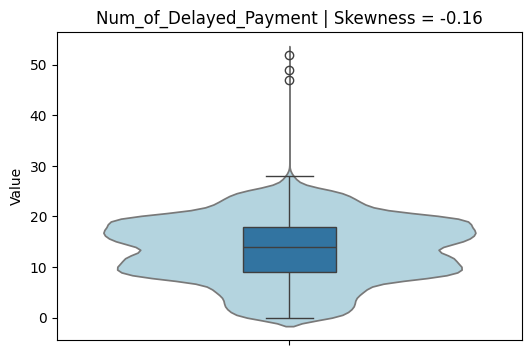

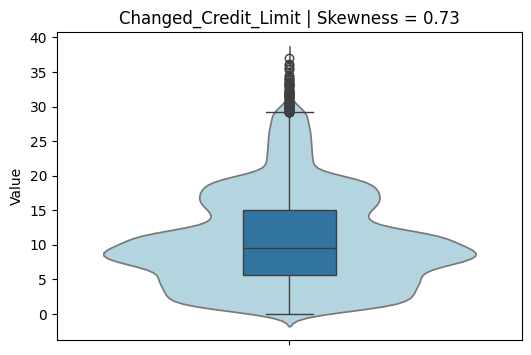

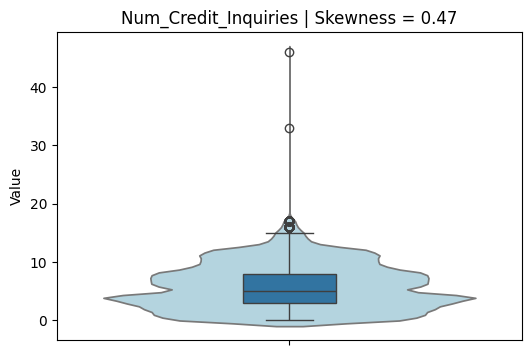

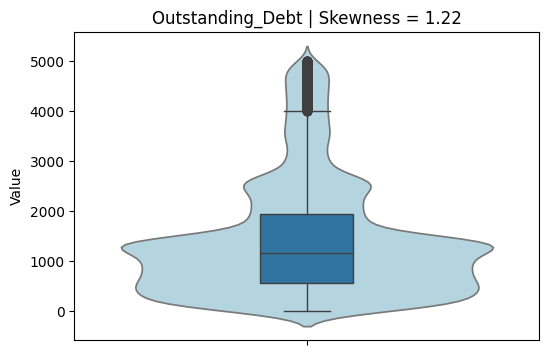

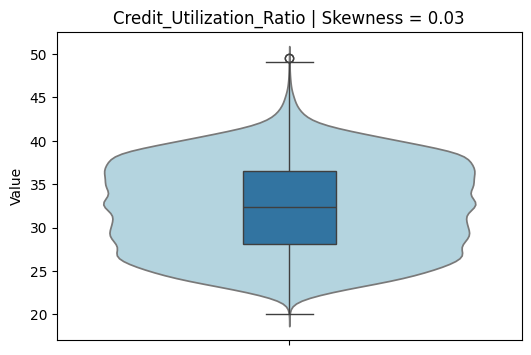

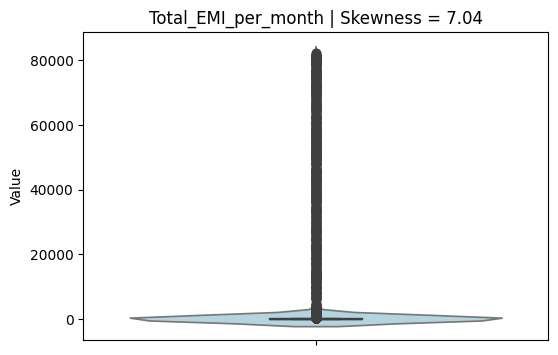

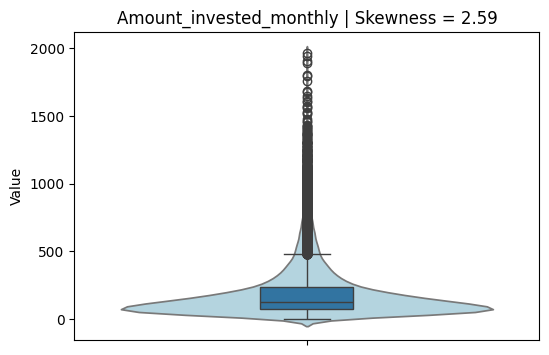

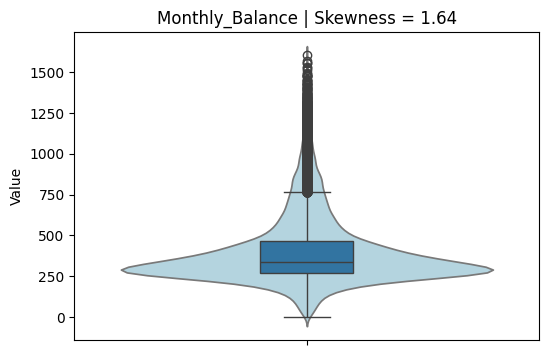

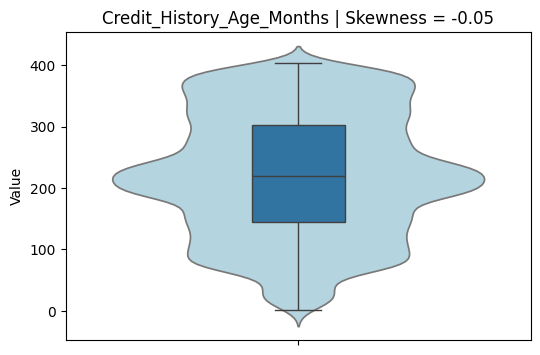

In [24]:
num_cols = df.select_dtypes(exclude=['object']).columns

for col in num_cols:
    plt.figure(figsize=(6,4))
    sns.violinplot(y=df[col], inner=None, color="lightblue")
    sns.boxplot(y=df[col], width=0.2)
    plt.title(f"{col} | Skewness = {df[col].skew():.2f}")
    plt.ylabel("Value")
    plt.show()

Skewness
- Fitur dengan **skewness ekstrem (Annual_Income, Monthly_Inhand_Salary, Outstanding_Debt, Total_EMI_per_month, Amount_invested_monthly, Monthly_Balance)** perlu perlakuan khusus sebelum modeling, terutama untuk model sensitif terhadap distribusi.
- Fitur lainnya  **relatif simetris** dan **sudah cukup stabil**.

Outliers    
Distribusi secara keseluruhan pada fitur menunjukkan **distribusi bersifat tidak normal dan terdapat beberapa outlier**, namun wajar karena ini mencerminkan heterogenitas perilaku kredit dan keterlambatan pembayaran antar nasabah, serta umum ditemukan pada data finansial berbasis hitungan.

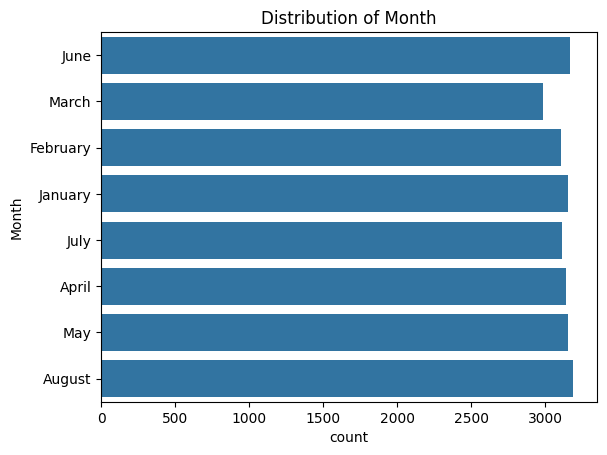

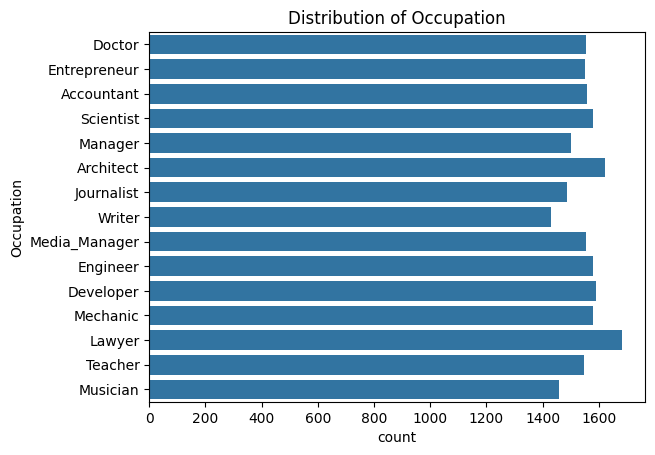

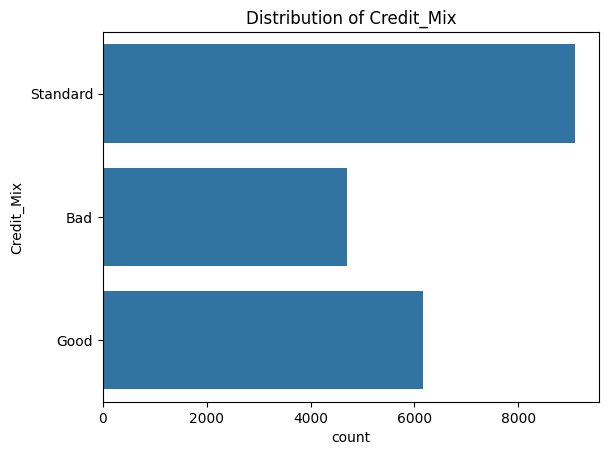

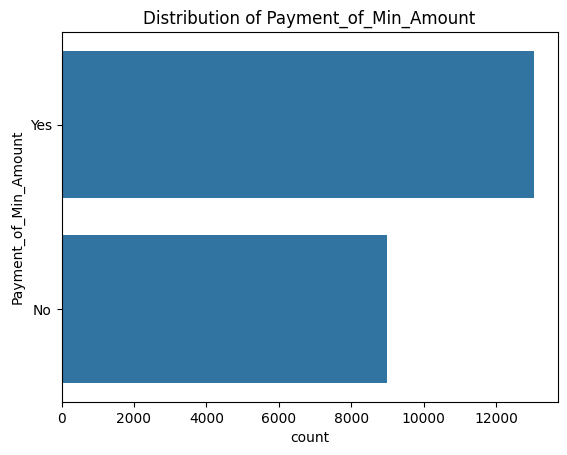

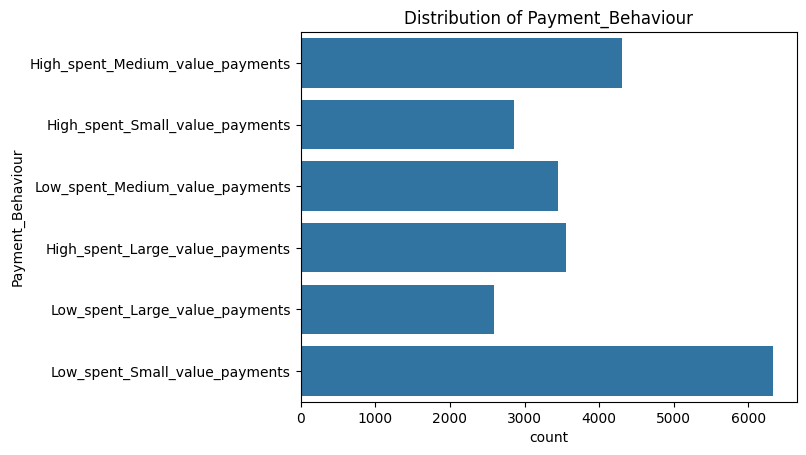

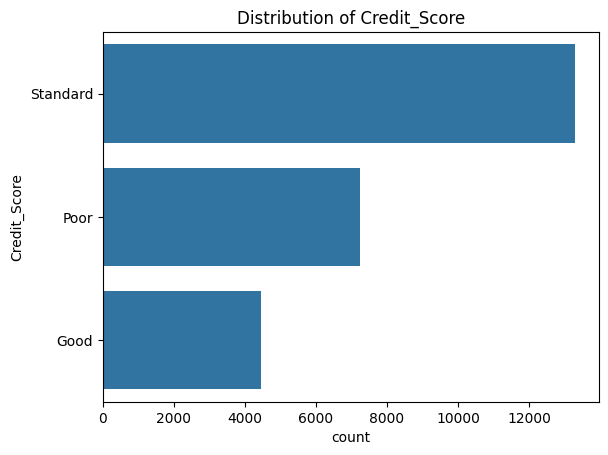

In [25]:
cat_cols = df.select_dtypes(include=['object']).columns

for col in cat_cols:
    sns.countplot(data=df, y=col)
    plt.title(f'Distribution of {col}')
    plt.show()

- **Month**   
Pada fitur **Month** distribusi untuk setiap kategori tidak jauh berbeda. Dengan **August** sebagai bulan yang paling banyak transaksi. Dan untuk **March** sebagai bulan yang paling sedikit transaksi.

- **Occupation**   
Pada fitur **Occupation**, kategori **Lawyer** memiliki **proporsi terbesar**, yang menunjukkan bahwa sebagian besar nasabah bekerja sebagai lawyer. Dan kategori **Writer** memiliki **proporsi paling kecil**, yang menunjukkan bahwa hanya sedikit nasabah yang bekerja sebagar writer. 

- **Credit_Mix**   
Pada fitur **Credit_Mix**, kategori **Standard** memiliki **proporsi terbesar**, yang menunjukkan bahwa sebagian besar nasabah berada pada profil kredit tingkat menengah. Sebaliknya, kategori **Bad** memiliki **proporsi paling kecil**, yang mengindikasikan bahwa hanya sedikit nasabah yang berada dalam kondisi kredit yang buruk.

- **Payment_of_Min_Amount**   
Distribusi fitur **Payment_of_Min_Amount** **didominasi oleh kategori Yes**, yang menunjukkan bahwa mayoritas nasabah melakukan pembayaran minimum setiap bulan. Sementara itu, **kategori No muncul dengan frekuensi yang lebih rendah**.

- **Payment_Behavior**   
Fitur **Payment_Behavior** menunjukkan distribusi yang tidak merata. Kategori **Low_spent_Small_value_payments merupakan kategori yang paling umum**, yang mengindikasikan bahwa sebagian besar nasabah melakukan transaksi bernilai kecil dengan tingkat pengeluaran yang relatif rendah. Sebaliknya, kategori **Low_spent_Large_value_payments merupakan yang paling jarang**, menunjukkan bahwa hanya sebagian kecil nasabah yang sering melakukan transaksi bernilai besar namun dengan volume pengeluaran yang rendah.

- **Credit_Score**   
Distribusi fitur target **Credit_Score** menunjukkan adanya **ketidakseimbangan kelas**, di mana kategori **Standard menjadi kelas mayoritas**, sementara **Good merupakan kelas minoritas** dengan proporsi yang jauh lebih kecil.

### Correlation

#### Check Association Between Numerical Variables

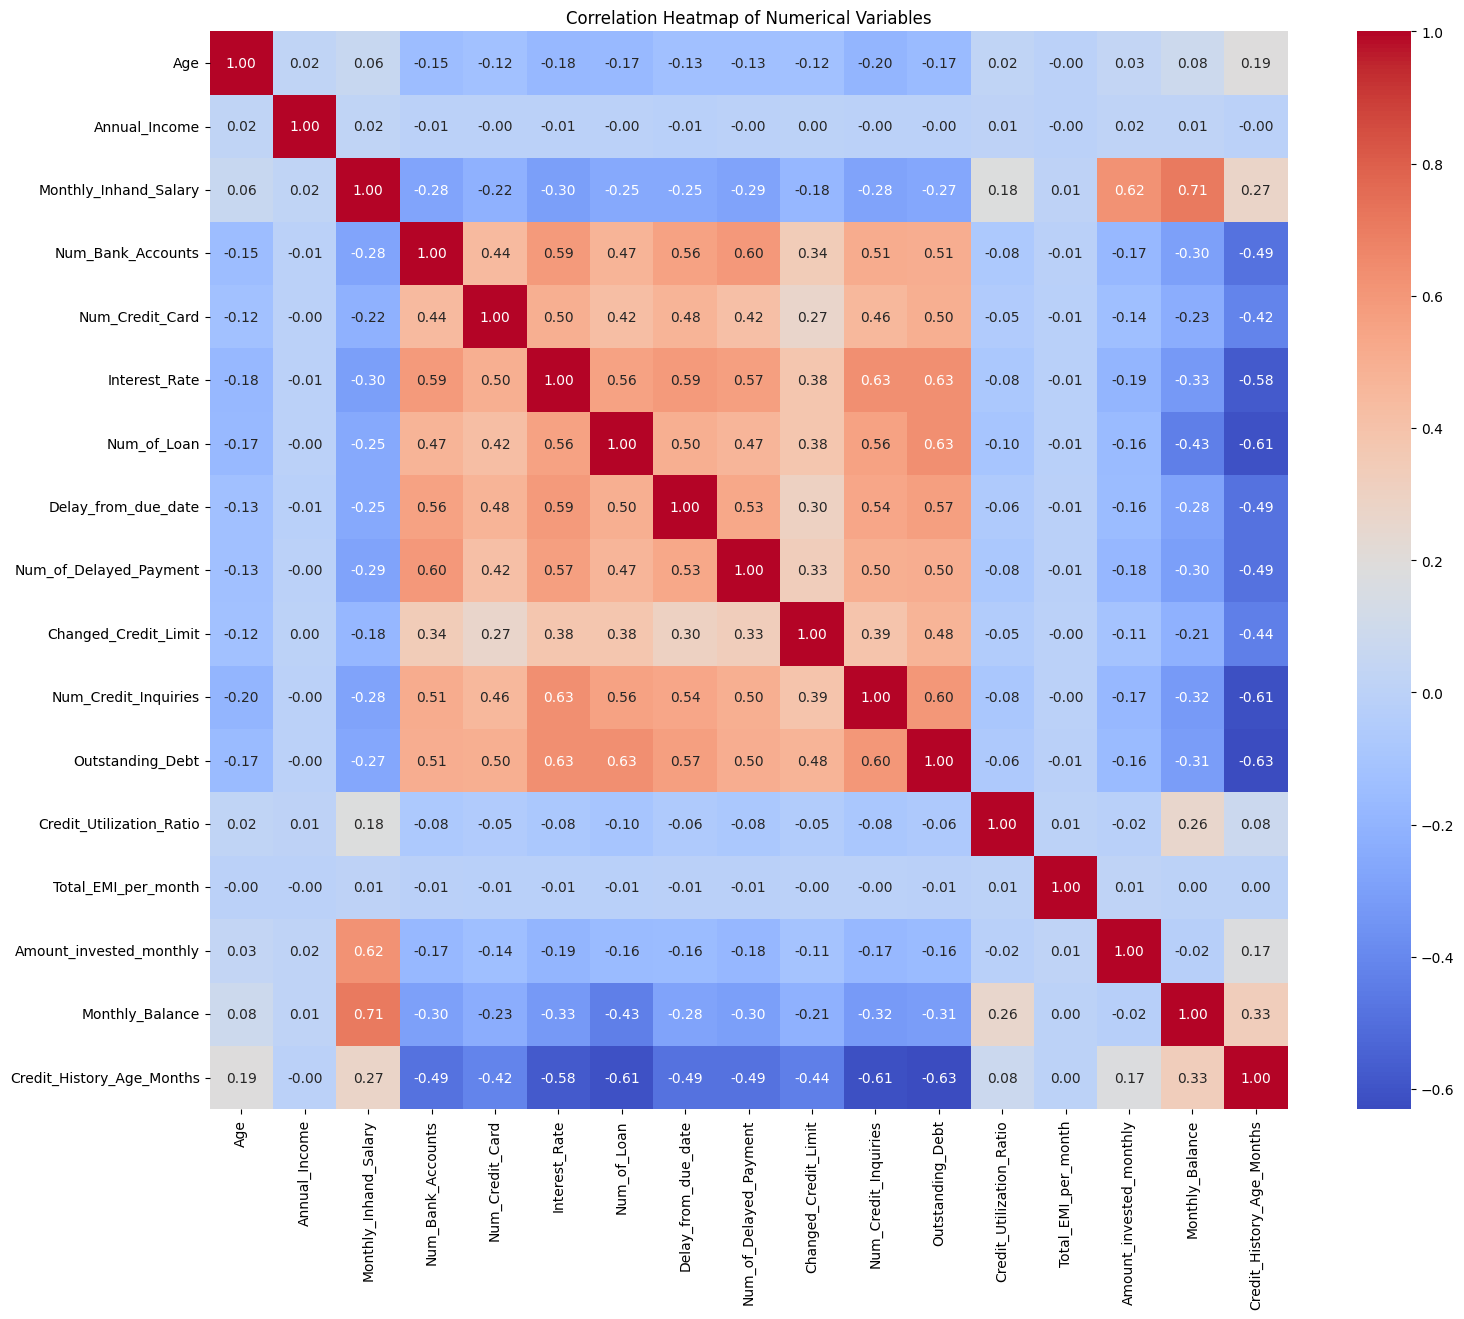

In [26]:
num_cols = df.select_dtypes(exclude=['object'])

corr_matrix = num_cols.corr()

plt.figure(figsize=(18, 14))
sns.heatmap(corr_matrix, annot = True, fmt = ".2f", cmap = "coolwarm", square=True)
plt.title("Correlation Heatmap of Numerical Variables")
plt.show()

Secara umum, matriks korelasi menunjukkan bahwa:
- Sebagian besar fitur memiliki **korelasi rendah hingga moderat, sehingga risiko multikolinearitas berlebihan relatif kecil** dan aman untuk digunakan dalam pemodelan.
- Namun, terdapat **beberapa kelompok fitur dengan korelasi sedang hingga kuat**, khususnya variabel yang berkaitan dengan **perilaku kredit, utang, dan keterlambatan pembayaran**, yang secara logis saling berkaitan.

**A. Kelompok "Beban Kredit dan Risiko"**   
Fitur-fitur berikut menunjukkan **korelasi positif sedang hingga kuat (≈ 0.45–0.65)** satu sama lain:
- **Outstanding_Debt**
- **Num_Credit_Inquiries**
- **Interest_Rate**
- **Num_of_Loan**
- **Delay_from_due_date**
- **Num_of_Delayed_Payment**
- **Num_Bank_Accounts**
- **Num_Credit_Card**    
Pola ini menunjukkan bahwa nasabah dengan **utang yang lebih tinggi** cenderung memiliki **jumlah pinjaman lebih banyak, suku bunga lebih tinggi, lebih sering melakukan credit inquiries, serta lebih sering mengalami keterlambatan pembayaran**. Hubungan ini konsisten dengan **logika domain kredit**, sehingga memperkuat validitas struktur data.

**B. Monthly_Inhand_Salary dan Kapasitas Finansial**   
**Monthly_Inhand_Salary** menunjukkan **korelasi positif yang cukup kuat** dengan:
- **Monthly_Balance (≈ 0.71)**
- **Amount_invested_monthly (≈ 0.62)**   
Hal ini mengindikasikan bahwa nasabah dengan **pendapatan bulanan lebih tinggi** cenderung memiliki **saldo akhir bulanan yang lebih besar** serta **kemampuan investasi yang lebih tinggi**, mencerminkan **fleksibilitas dan stabilitas finansial yang lebih baik**.

**C. Credit_History_Age_Months**   
**Credit_History_Age_Months** memiliki **korelasi negatif yang cukup kuat** dengan:
- **Outstanding_Debt (≈ -0.63)**
- **Num_Credit_Inquiries (≈ -0.61)**
- **Num_of_Loan (≈ -0.61)**
- **Interest_Rate (≈ -0.58)**
- **Delay_from_due_date dan Num_of_Delayed_Payment (≈ -0.49)**   
Artinya, nasabah dengan **riwayat kredit yang lebih panjang** cenderung memiliki **utang lebih rendah, lebih sedikit pinjaman, lebih jarang mengajukan kredit baru, serta tingkat bunga yang lebih rendah**, yang mencerminkan **profil kredit yang lebih matang dan stabil**.

**D. Annual_Income**   
Menunjukkan **korelasi yang sangat lemah (mendekati 0)** dengan hampir seluruh fitur lainnya. Kondisi ini mengindikasikan bahwa **pendapatan tahunan tidak terhubung secara linear** dengan variabel finansial lainnya dalam dataset, kemungkinan disebabkan oleh **distribusi yang sangat skewed, outlier ekstrem, atau ketidakkonsistenan pelaporan nilai**. Oleh karena itu, fitur ini tidak dihapus, tetapi **ditangani melalui transformasi logaritmik** untuk menstabilkan distribusi dan meningkatkan kualitas informasi yang dapat dimanfaatkan oleh model.

In [27]:
df['Annual_Income_log'] = np.log1p(df['Annual_Income'])

In [28]:
df = df.drop(columns=['Annual_Income'])

#### Check Association Between Numerical Variables and Categorical Target Variable

In [29]:
num_cols = df.select_dtypes(include=['int64','float64']).columns

results = []

for col in num_cols:
    g_good = df[df['Credit_Score'] == 'Good'][col].dropna()
    g_standard = df[df['Credit_Score'] == 'Standard'][col].dropna()
    g_poor = df[df['Credit_Score'] == 'Poor'][col].dropna()

    if min(len(g_good), len(g_standard), len(g_poor)) > 0:
        h_stat, p = kruskal(g_good, g_standard, g_poor)
        results.append([col, h_stat, p])

kw_df = pd.DataFrame(results, columns=['Numerical_Feature', 'H_statistic', 'p_value']).sort_values(by='p_value')
kw_df

,Numerical_Feature,H_statistic,p_value
2,Num_Bank_Accounts,3787.334476,0.000000e+00
3,Num_Credit_Card,3638.167706,0.000000e+00
4,Interest_Rate,5570.180843,0.000000e+00
5,Num_of_Loan,3001.235583,0.000000e+00
6,Delay_from_due_date,4610.467037,0.000000e+00
7,Num_of_Delayed_Payment,3201.718235,0.000000e+00
15,Credit_History_Age_Months,3576.704276,0.000000e+00
9,Num_Credit_Inquiries,4565.663835,0.000000e+00
10,Outstanding_Debt,5023.012588,0.000000e+00
14,Monthly_Balance,1305.216292,3.766026e-284


Karena **seluruh nilai p-value berada di bawah tingkat signifikansi 0,05**, maka hipotesis nol (H₀) ditolak untuk seluruh variabel numerik. Hal ini menunjukkan bahwa terdapat **perbedaan distribusi yang signifikan secara statistik pada variabel-variabel tersebut di antara kategori Credit_Score** (Good, Standard, dan Poor).

Variabel seperti **Interest_Rate, Outstanding_Debt, Delay_from_due_date, Num_Credit_Inquiries, dan Num_Bank_Accounts** memiliki nilai **H-statistic** yang tinggi, sehingga menunjukkan hubungan yang lebih kuat dengan **Credit_Score**. Karena seluruh variabel signifikan secara statistik, semua fitur numerik dipertahankan untuk tahap pemodelan selanjutnya.

#### Check Association Between Categorical Variables

In [30]:
def cramers_v(x, y):
    confusion_matrix = pd.crosstab(x, y)
    chi2 = chi2_contingency(confusion_matrix)[0]
    n = confusion_matrix.sum().sum()
    phi2 = chi2 / n
    r, k = confusion_matrix.shape
    return np.sqrt(phi2 / min(k - 1, r - 1))

cat_cols = df.select_dtypes(include=["object"]).columns
cat_cols = [c for c in cat_cols if c not in ["Credit_Score"]]

cramers_matrix = pd.DataFrame(index=cat_cols, columns=cat_cols)

for col1 in cat_cols:
    for col2 in cat_cols:
        cramers_matrix.loc[col1, col2] = cramers_v(df[col1], df[col2])

cramers_matrix = cramers_matrix.astype(float)

print("Cramer's V between categorical features")
cramers_matrix.round(3)

Cramer's V between categorical features


,Month,Occupation,Credit_Mix,Payment_of_Min_Amount,Payment_Behaviour
Month,1.000,0.018,0.020,0.017,0.017
Occupation,0.018,1.000,0.043,0.030,0.026
Credit_Mix,0.020,0.043,1.000,0.819,0.084
Payment_of_Min_Amount,0.017,0.030,0.819,1.000,0.109
Payment_Behaviour,0.017,0.026,0.084,0.109,1.000


Secara umum, **sebagian besar variabel kategorikal menunjukkan hubungan yang sangat lemah satu sama lain** (Cramer’s V < 0,10). Hal ini mengindikasikan **minimnya multikolinearitas** antar fitur kategorikal, yang baik untuk proses pemodelan.

Namun, terdapat **satu hubungan yang sangat kuat**, yaitu:
**Credit_Mix dan Payment_of_Min_Amount (Cramer’s V = 0,82)**. Hubungan ini menunjukkan bahwa **komposisi jenis kredit yang dimiliki nasabah sangat berkaitan dengan pola pembayaran minimum**. Hal ini logis secara domain kredit, karena nasabah dengan kombinasi kredit yang lebih kompleks cenderung memiliki kewajiban pembayaran minimum yang lebih jelas atau konsisten.

In [31]:
target = "placement_status"

cramer_results = {}

for col in cat_cols:
    cramer_results[col] = cramers_v(df[col], df["Credit_Score"])

cramer_df = pd.DataFrame.from_dict(cramer_results, orient="index", columns=["Cramers_V"])
print(cramer_df.sort_values("Cramers_V", ascending=False).round(3))

                       Cramers_V
Payment_of_Min_Amount      0.465
Credit_Mix                 0.439
Payment_Behaviour          0.087
Occupation                 0.037
Month                      0.037


Berdasarkan nilai Cramer's V terhadap Credit_Score, dapat disimpulkan bahwa:
- **Payment_of_Min_Amount (0,465) dan Credit_Mix (0,439)** memiliki **asosiasi moderat hingga kuat** dengan Credit_Score. Artinya, perilaku membayar minimum dan komposisi kredit merupakan faktor kategorikal yang **paling informatif** dalam membedakan kualitas kredit nasabah.
- **Payment_Behaviour (0,087)** memiliki hubungan **lemah**, namun masih menunjukkan sedikit perbedaan pola antar kelas kredit.
- **Occupation (0,037) dan Month (0,037)** menunjukkan **asosiasi yang sangat lemah** dengan Credit_Score, sehingga kontribusinya terhadap prediksi kualitas kredit relatif kecil. Sehingga fitur ini sebaiknya **dihapus** dari dataset untuk **mengurangi noise, menghindari redundansi informasi, dan meningkatkan efisiensi kinerja model prediksi**.

In [32]:
df = df.drop(columns=["Month", "Occupation"])

## Splitting Data

In [33]:
x = df.drop(columns=["Credit_Score"])

label_mapping = {'Poor': 0, 'Standard': 1, 'Good': 2}
y = df["Credit_Score"].map(label_mapping)

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42, stratify=y)

Dataset dibagi menjadi **80% training dan 20% testing**.    
stratify digunakan untuk menjaga distribusi kelas tetap seimbang karena data imbalance

In [34]:
num_cols = x.select_dtypes(include=['int64', 'float64']).columns.tolist()
cat_cols = x.select_dtypes(include=['object']).columns.tolist()

## Preprocessing Pipeline

### Numerical Pipeline

In [35]:
num_pipeline = Pipeline([('imputer', SimpleImputer(strategy='median'))])

### Categorical Pipeline

In [36]:
credit_mix_pipeline = Pipeline([('imputer', SimpleImputer(strategy='most_frequent')),
                                ('encoder', OrdinalEncoder(categories=[['Bad', 'Standard', 'Good']]))])

In [37]:
payment_min_pipeline = Pipeline([('imputer', SimpleImputer(strategy='most_frequent')),
                                 ('encoder', OrdinalEncoder(categories=[['No', 'Yes']]))])

In [38]:
payment_behaviour_pipeline = Pipeline([('imputer', SimpleImputer(strategy='most_frequent')),
                                       ('encoder', OneHotEncoder(drop='first', handle_unknown='ignore'))])

Variabel **ordinal** dikodekan menggunakan **ordinal mapping** untuk mempertahankan urutan alaminya, variabel **biner** dikodekan menggunakan **representasi biner**, dan variabel **nominal** ditransformasikan menggunakan **one-hot encoding**.

### Penggabungan

In [39]:
preprocessor = ColumnTransformer([('num', num_pipeline, num_cols),
                                  ('credit_mix', credit_mix_pipeline, ['Credit_Mix']),
                                  ('payment_min', payment_min_pipeline, ['Payment_of_Min_Amount']),
                                  ('payment_behaviour', payment_behaviour_pipeline, ['Payment_Behaviour'])])

Preprocessing dilakukan menggunakan pipeline untuk menghindari data leakage dan memastikan konsistensi saat deployment.
- **Numerical : missing value -> imputasi median dan tanpa scaling karena menggunakan model berbasis tree**
- **Categorical : missing value ->  imputasi modus dan dilakukan ordinal encoding (Credit_Mix), binary encoding (Payment_of_Min_Amount), dan one hot encoding (Payment_Behaviour)**

## Modeling

#### Baseline Modeling

In [40]:
models = {
    "Decision Tree":DecisionTreeClassifier(random_state=42, class_weight='balanced'),
    "Random Forest":RandomForestClassifier(random_state=42, class_weight='balanced'),
    "Gradient Boosting":GradientBoostingClassifier(random_state=42),
    "XGBoost":XGBClassifier(objective='multi:softprob', eval_metric='mlogloss', random_state=42)
    }

Untuk handling imbalance, digunakan class_weight pada Decision Tree, Random Forest, Gradient Boosting, dan XGBoost.

In [41]:
results = []

for name, model in models.items():
    pipeline = Pipeline([('preprocessing', preprocessor),
                         ('model', model)])
    
    pipeline.fit(x_train, y_train)

    y_pred = pipeline.predict(x_test)
    y_proba_train = pipeline.predict_proba(x_train)
    y_proba_test = pipeline.predict_proba(x_test)

    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, average='weighted')
    train_auc = roc_auc_score(y_train, y_proba_train, multi_class='ovr', average='macro')
    test_auc = roc_auc_score(y_test, y_proba_test, multi_class='ovr', average='macro')

    print(f"\n===== {name} =====")
    print(f"Accuracy : {acc:.4f}")
    print(f"Weighted F1 : {f1:.4f}")
    print(f"Train AUC : {train_auc:.4f}")
    print(f"Test AUC : {test_auc:.4f}")
    print("\nClassification Report")
    print(classification_report(y_test, y_pred))
    results.append({"Model": name,
                    "Accuracy": acc,
                    "F1_Weighted": f1,
                    "Train_AUC": train_auc,
                    "Test_AUC": test_auc})


===== Decision Tree =====
Accuracy : 0.6220
Weighted F1 : 0.6216
Train AUC : 1.0000
Test AUC : 0.6882

Classification Report
              precision    recall  f1-score   support

           0       0.58      0.61      0.60      1446
           1       0.68      0.67      0.68      2661
           2       0.51      0.48      0.50       893

    accuracy                           0.62      5000
   macro avg       0.59      0.59      0.59      5000
weighted avg       0.62      0.62      0.62      5000


===== Random Forest =====
Accuracy : 0.7216
Weighted F1 : 0.7190
Train AUC : 1.0000
Test AUC : 0.8723

Classification Report
              precision    recall  f1-score   support

           0       0.74      0.71      0.72      1446
           1       0.73      0.79      0.76      2661
           2       0.65      0.54      0.59       893

    accuracy                           0.72      5000
   macro avg       0.71      0.68      0.69      5000
weighted avg       0.72      0.72      0.

In [42]:
results_df = pd.DataFrame(results)
results_df = results_df.sort_values(by='F1_Weighted', ascending=False)
results_df

,Model,Accuracy,F1_Weighted,Train_AUC,Test_AUC
1,Random Forest,0.7216,0.718951,1.000000,0.872258
3,XGBoost,0.7084,0.707782,0.981450,0.858366
2,Gradient Boosting,0.6922,0.691157,0.863635,0.845220
0,Decision Tree,0.6220,0.621643,1.000000,0.688185


Dari hasil baseline, **Random Forest, XGBoost, dan Gradient Boosting** menunjukkan performa terbaik dengan nilai Accuracy, Weighted F1-Score, dan Test AUC yang lebih tinggi dibandingkan Decision Tree. Oleh karena itu, ketiga model tersebut dipilih untuk dilakukan **hyperparameter tuning**.

#### Hyperparameter Tuning Random Forest

In [43]:
rf_pipeline = Pipeline([('preprocessing', preprocessor),
                        ('model', RandomForestClassifier(random_state=42, class_weight='balanced'))])

rf_param_grid = {'model__n_estimators': [100, 300, 500],
                 'model__max_depth': [10, 20, None],
                 'model__min_samples_split': [2, 5, 10]}

rf_grid = GridSearchCV(estimator=rf_pipeline,
                       param_grid=rf_param_grid,
                       scoring='f1_weighted',
                       cv=5,
                       n_jobs=-1,
                       verbose=1)

rf_grid.fit(x_train, y_train)

print("Best RF Parameters:", rf_grid.best_params_)

Fitting 5 folds for each of 27 candidates, totalling 135 fits
Best RF Parameters: {'model__max_depth': None, 'model__min_samples_split': 5, 'model__n_estimators': 500}


In [44]:
rf_best = rf_grid.best_estimator_
rf_best_pred = rf_best.predict(x_test)

rf_best_proba_train = rf_best.predict_proba(x_train)
rf_best_proba_test = rf_best.predict_proba(x_test)

rf_best_auc_train = roc_auc_score(y_train, rf_best_proba_train, multi_class="ovr", average="macro")
rf_best_auc_test = roc_auc_score(y_test, rf_best_proba_test, multi_class="ovr", average="macro")

print("Confusion Matrix:")
print(confusion_matrix(y_test, rf_best_pred))
print("\nClassification Report (Random Forest Tuned):")
print(classification_report(y_test, rf_best_pred))
print(f"Train AUC (OvR): {rf_best_auc_train:.4f}")
print(f"Test AUC (OvR): {rf_best_auc_test:.4f}")

Confusion Matrix:
[[1049  307   90]
 [ 359 2006  296]
 [  16  278  599]]

Classification Report (Random Forest Tuned):
              precision    recall  f1-score   support

           0       0.74      0.73      0.73      1446
           1       0.77      0.75      0.76      2661
           2       0.61      0.67      0.64       893

    accuracy                           0.73      5000
   macro avg       0.71      0.72      0.71      5000
weighted avg       0.73      0.73      0.73      5000

Train AUC (OvR): 0.9999
Test AUC (OvR): 0.8722


**Confusion Matrix**   
Hasil confusion matrix menunjukkan bahwa **sebagian besar observasi berhasil diklasifikasikan dengan benar**. Kesalahan klasifikasi masih paling sering terjadi pada kelas Poor dan Good yang diprediksi sebagai Standard, menunjukkan bahwa kelas Standard memiliki karakteristik yang relatif beririsan dengan kedua kelas lainnya.

**Precision, Recall, dan F1-score**
- **Standard** memberikan performa terbaik dengan **F1-score sebesar 0.76**.
- **Poor** memperoleh **F1-score sebesar 0.73**.
- **Good** memperoleh **F1-score sebesar 0.64**, meningkat dibandingkan model baseline.
Nilai **Weighted F1-score sebesar 0.73** menunjukkan performa **klasifikasi yang baik secara keseluruhan pada seluruh kelas**.

**Accuracy**   
Model menghasilkan **Accuracy sebesar 73%**, meningkat dibandingkan baseline Random Forest (72.16%).

**AUC**   
**Train AUC = 0.9999**   
**Test AUC = 0.8722**

Nilai **Test AUC yang tinggi menunjukkan kemampuan model dalam membedakan ketiga kelas Credit Score dengan sangat baik**. Meskipun Train AUC mendekati sempurna, performa pada data testing tetap stabil sehingga model masih memiliki kemampuan generalisasi yang baik.

#### Hyperparameter Tuning XGBoost

In [45]:
xgb_pipeline = Pipeline([('preprocessing', preprocessor),
                         ('model', XGBClassifier(objective='multi:softprob', eval_metric='mlogloss', random_state=42))])

xgb_param_grid = {"model__n_estimators": [200, 300],
                  "model__max_depth": [4, 6],
                  "model__learning_rate": [0.05, 0.1]}

xgb_grid = GridSearchCV(xgb_pipeline,
                          xgb_param_grid,
                          scoring='f1_weighted',
                          cv=5,
                          n_jobs=-1,
                          verbose=1)

xgb_grid.fit(x_train, y_train)

print("Best XGB Parameters:", xgb_grid.best_params_)

Fitting 5 folds for each of 8 candidates, totalling 40 fits
Best XGB Parameters: {'model__learning_rate': 0.1, 'model__max_depth': 6, 'model__n_estimators': 300}


In [46]:
xgb_best = xgb_grid.best_estimator_
xgb_best_pred = xgb_best.predict(x_test)

xgb_best_proba_train = xgb_best.predict_proba(x_train)
xgb_best_proba_test = xgb_best.predict_proba(x_test)

xgb_best_auc_train = roc_auc_score(y_train, xgb_best_proba_train, multi_class="ovr", average="macro")
xgb_best_auc_test = roc_auc_score(y_test, xgb_best_proba_test, multi_class="ovr", average="macro")

print("Confusion Matrix:")
print(confusion_matrix(y_test, xgb_best_pred))
print("\nClassification Report (XGBoost Tuned):")
print(classification_report(y_test, xgb_best_pred))
print(f"Train AUC (OvR): {xgb_best_auc_train:.4f}")
print(f"Test AUC (OvR): {xgb_best_auc_test:.4f}")

Confusion Matrix:
[[1009  363   74]
 [ 366 2032  263]
 [  18  338  537]]

Classification Report (XGBoost Tuned):
              precision    recall  f1-score   support

           0       0.72      0.70      0.71      1446
           1       0.74      0.76      0.75      2661
           2       0.61      0.60      0.61       893

    accuracy                           0.72      5000
   macro avg       0.69      0.69      0.69      5000
weighted avg       0.71      0.72      0.72      5000

Train AUC (OvR): 0.9790
Test AUC (OvR): 0.8606


**Confusion Matrix**   
Kesalahan klasifikasi masih dominan terjadi antara kelas Poor, Good, dan Standard. **Dibandingkan Random Forest, jumlah prediksi yang berpindah ke kelas Standard masih relatif lebih tinggi**.

**Precision, Recall, dan F1-score**
- **Standard** menjadi kelas dengan performa terbaik **F1-score sebesar 0.75**.
- **Poor** memperoleh **F1-score sebesar 0.71**.
- **Good** memperoleh **F1-score sebesar 0.61**.
Nilai **Weighted F1-score sebesar 0.72** menunjukkan performa **performa yang baik dan relatif seimbang pada seluruh kelas**.

**Accuracy**   
Model menghasilkan **Accuracy sebesar 72%** sedikit lebih baik dibandingkan baseline XGBoost (70.84%).

**AUC**   
**Train AUC = 0.9790**   
**Test AUC = 0.8606**

**Nilai AUC menunjukkan kemampuan diskriminasi kelas yang kuat**. Selisih antara Train AUC dan Test AUC relatif kecil sehingga model tidak menunjukkan indikasi overfitting yang signifikan.

#### Hyperparameter Tuning Gradient Boosting

In [47]:
gb_pipeline = Pipeline([('preprocessing', preprocessor),
                        ('model', GradientBoostingClassifier(random_state=42))])

gb_param_grid = {"model__n_estimators": [100, 200],
                 "model__learning_rate": [0.05, 0.1],
                 "model__max_depth": [3, 5]}

gb_grid = GridSearchCV(estimator=gb_pipeline,
                       param_grid=gb_param_grid,
                       scoring='f1_weighted',
                       cv=5,
                       n_jobs=-1,
                       verbose=1)

gb_grid.fit(x_train, y_train)

print("Best GB Parameters:", gb_grid.best_params_)

Fitting 5 folds for each of 8 candidates, totalling 40 fits
Best GB Parameters: {'model__learning_rate': 0.1, 'model__max_depth': 5, 'model__n_estimators': 200}


In [48]:
gb_best = gb_grid.best_estimator_
gb_best_pred = gb_best.predict(x_test)

gb_best_proba_train = gb_best.predict_proba(x_train)
gb_best_proba_test = gb_best.predict_proba(x_test)

gb_best_auc_train = roc_auc_score(y_train, gb_best_proba_train, multi_class="ovr", average="macro")
gb_best_auc_test = roc_auc_score(y_test, gb_best_proba_test, multi_class="ovr", average="macro")

print("Confusion Matrix:")
print(confusion_matrix(y_test, gb_best_pred))
print("\nClassification Report (Gradient Boosting Tuned):")
print(classification_report(y_test, gb_best_pred))
print(f"Train AUC (OvR): {gb_best_auc_train:.4f}")
print(f"Test AUC (OvR): {gb_best_auc_test:.4f}")

Confusion Matrix:
[[1022  343   81]
 [ 372 2010  279]
 [  19  335  539]]

Classification Report (Gradient Boosting Tuned):
              precision    recall  f1-score   support

           0       0.72      0.71      0.71      1446
           1       0.75      0.76      0.75      2661
           2       0.60      0.60      0.60       893

    accuracy                           0.71      5000
   macro avg       0.69      0.69      0.69      5000
weighted avg       0.71      0.71      0.71      5000

Train AUC (OvR): 0.9443
Test AUC (OvR): 0.8585


**Confusion Matrix**   
Pola kesalahan klasifikasi mirip dengan XGBoost, di mana **sebagian data kelas Poor dan Good masih sering diprediksi sebagai Standard**.

**Precision, Recall, dan F1-score**
- **Standard** tetap menjadi kelas dengan performa terbaik **F1-score sebesar 0.75**.
- **Poor** memperoleh **F1-score sebesar 0.71**.
- **Good** memperoleh **F1-score sebesar 0.60**.
Nilai **Weighted F1-score sebesar 0.71** menunjukkan **performa yang cukup baik dan stabil pada seluruh kelas**.

**Accuracy**   
Model menghasilkan **Accuracy sebesar 71%** sedikit lebih baik dibandingkan baseline Gradient Boosting (69.22%).

**AUC**   
**Train AUC = 0.9443**   
**Test AUC = 0.8585**

**Nilai AUC menunjukkan kemampuan pemisahan kelas yang baik**. Selisih Train AUC dan Test AUC relatif kecil sehingga model memiliki generalisasi yang cukup baik terhadap data yang belum pernah dilihat sebelumnya.

#### Final Model

In [50]:
rf_report = classification_report(y_test, rf_best_pred, output_dict=True)
xgb_report = classification_report(y_test, xgb_best_pred, output_dict=True)
gb_report = classification_report(y_test, gb_best_pred, output_dict=True)

comparison = pd.DataFrame({
    "Model": ["Random Forest", "XGBoost", "Gradient Boosting"],
    "Accuracy": [accuracy_score(y_test, rf_best_pred),
                 accuracy_score(y_test, xgb_best_pred),
                 accuracy_score(y_test, gb_best_pred)],
    "Weighted_F1": [rf_report["weighted avg"]["f1-score"],
                    xgb_report["weighted avg"]["f1-score"],
                    gb_report["weighted avg"]["f1-score"]],
    "Test_AUC": [rf_best_auc_test, 
                 xgb_best_auc_test, 
                 gb_best_auc_test]})

comparison = comparison.round(4)
comparison.sort_values(by="Weighted_F1", ascending=False)

,Model,Accuracy,Weighted_F1,Test_AUC
0,Random Forest,0.7308,0.7319,0.8722
1,XGBoost,0.7156,0.7151,0.8606
2,Gradient Boosting,0.7142,0.7142,0.8585


Setelah dilakukan hyperparameter tuning, seluruh model mengalami peningkatan performa dibandingkan model baseline. Berdasarkan hasil evaluasi,**Random Forest** menjadi model terbaik dengan **Accuracy 73.08%, Weighted F1-score 73.19%, dan Test AUC 0.8722**. Posisi berikutnya ditempati oleh **XGBoost** dengan **Accuracy 71.56%, Weighted F1-score 71.51%, dan Test AUC 0.8606**, diikuti oleh **Gradient Boosting** dengan performa yang sedikit lebih rendah.

Berdasarkan hasil tersebut, **Random Forest dan XGBoost dipilih sebagai dua model terbaik** untuk tahap pengembangan pipeline berbasis OOP dan MLflow. Random Forest dipilih sebagai model utama karena memberikan performa tertinggi, sedangkan XGBoost digunakan sebagai model pembanding karena memiliki performa yang masih kompetitif.